In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mooccubex-data-cleaned/course_filtered.csv
/kaggle/input/mooccubex-data-cleaned/label_3_5(have_start_end).csv
/kaggle/input/mooccubex-data-cleaned/Exercise/problem_df_cleaned.parquet
/kaggle/input/mooccubex-data-cleaned/Exercise/resource_exercise_course_have_problem_info.parquet
/kaggle/input/mooccubex-data-cleaned/Exercise/user-problem_cleaned.parquet
/kaggle/input/mooccubex-data-cleaned/Exercise/code/user_problem_processing.ipynb
/kaggle/input/mooccubex-data-cleaned/Exercise/code/user-course + time series.ipynb
/kaggle/input/mooccubex-data-cleaned/Exercise/code/prerocessing_problem.ipynb
/kaggle/input/mooccubex-data-cleaned/Exercise/code/user_problem_time_series.ipynb
/kaggle/input/mooccubex-data-cleaned/Exercise/final_split_phase/merge_phase_2_merged.csv
/kaggle/input/mooccubex-data-cleaned/Exercise/final_split_phase/merge_phase_1_merged.csv
/kaggle/input/mooccubex-data-cleaned/Exercise/final_split_phase/merge_phase_3_merged.csv
/kaggle/input/mooccubex-data-cleaned/Exe

In [2]:
!pip install -U scikit-learn==1.4.2 imbalanced-learn==0.12.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE

plt.rcParams["figure.figsize"] = (6, 4)


In [4]:
# =========================
# 2. Hàm vẽ biểu đồ + thống kê nhãn
# =========================
def describe_and_plot_labels(df, target_col: str, title_prefix: str):
    counts = df[target_col].value_counts().sort_index()
    
    print(f"\n=== {title_prefix} – thống kê nhãn ({target_col}) ===")
    print(counts)
    print("Tổng số mẫu:", counts.sum())
    
    if counts.min() > 0 and len(counts) > 1:
        maj = counts.max()
        mino = counts.min()
        print(f"Imbalance ratio (majority/minority): {maj/mino:.2f}")
    
    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"{title_prefix} – phân bố nhãn")
    plt.xlabel("Label")
    plt.ylabel("Số mẫu")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [5]:
# =========================
# 3. Hàm CDSMOTE cho multi-class (5 nhãn)
# =========================
def cdsmote_resample_multiclass(
    df: pd.DataFrame,
    feature_cols,
    target_col: str,
    k_clusters: int = 2,
    k_neighbors: int = 4,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    CDSMOTE cho bài toán multi-class (ví dụ 5 nhãn).
    Làm lần lượt one-vs-rest cho từng lớp thiểu số.
    """
    df = df.copy()
    X = df[feature_cols].values
    y = df[target_col].values

    classes, counts = np.unique(y, return_counts=True)
    class_counts = dict(zip(classes, counts))
    max_count = counts.max()

    print("=== CDSMOTE multi-class ===")
    print("Phân bố nhãn ban đầu:", class_counts)
    print("Max count (majority lớn nhất):", max_count)

    new_samples_per_class = []

    for cls in classes:
        n_cls = class_counts[cls]
        print(f"\n--- Xử lý class = {cls} ---")
        print(f"  - Số mẫu class {cls}: {n_cls}")

        # Bỏ qua class majority hoặc quá ít mẫu
        if n_cls >= max_count:
            print("  -> Đây là majority (hoặc gần bằng majority), bỏ qua oversampling.")
            continue
        if n_cls < 2:
            print("  -> Số mẫu < 2, không thể chạy SMOTE, bỏ qua.")
            continue

        # Minority = cls, Majority = các lớp khác
        idx_min = np.where(y == cls)[0]
        idx_maj = np.where(y != cls)[0]

        X_min = X[idx_min]
        X_maj = X[idx_maj]

        print(f"  - Số mẫu majority (y != {cls}): {X_maj.shape[0]}")

        # Không đủ majority để KMeans
        if X_maj.shape[0] < k_clusters:
            print("  -> Majority quá ít để KMeans, bỏ qua CDSMOTE cho class này.")
            continue

        # Decompose majority bằng KMeans
        kmeans = KMeans(
            n_clusters=k_clusters,
            random_state=random_state,
            n_init=10
        )
        maj_clusters = kmeans.fit_predict(X_maj)

        cluster_counts = np.bincount(maj_clusters, minlength=k_clusters)
        mean_maj = cluster_counts.mean()

        print(f"  - Số mẫu từng subclass majority: {cluster_counts.tolist()}")
        print(f"  - Mean size các subclass majority: {mean_maj:.2f}")

        # Nếu minority >= mean_maj thì không cần oversample class này
        if n_cls >= mean_maj:
            print("  -> Số mẫu class này >= mean_maj, không oversample.")
            continue

        # Chọn subclass gần mean nhất
        closest_cluster = np.argmin(np.abs(cluster_counts - mean_maj))
        print(f"  - Chọn subclass majority gần mean nhất: cluster {closest_cluster}")

        idx_maj_cluster = idx_maj[maj_clusters == closest_cluster]

        # SMOTE one-vs-rest:
        #  minority = 1, majority = 0
        X_smote = np.vstack([X_min, X[idx_maj_cluster]])
        y_smote = np.concatenate([
            np.ones(len(X_min), dtype=int),
            np.zeros(len(idx_maj_cluster), dtype=int),
        ])

        # Mục tiêu: class cls sau SMOTE ≈ mean_maj
        target_minority = int(round(mean_maj))
        print(f"  - Mục tiêu sau SMOTE: {target_minority} mẫu cho class {cls}")

        # Điều chỉnh k_neighbors cho hợp lệ
        k_eff = min(k_neighbors, len(X_min) - 1)
        if k_eff < 1:
            print("  -> Không đủ hàng xóm để SMOTE, bỏ qua.")
            continue

        smote = SMOTE(
            sampling_strategy={1: target_minority},
            k_neighbors=k_eff,
            random_state=random_state,
        )

        X_res, y_res = smote.fit_resample(X_smote, y_smote)

        # Lấy mẫu minority synthetic mới (label 1 trong y_res)
        n_minority_after = (y_res == 1).sum()
        n_new = n_minority_after - n_cls
        print(f"  - Số mẫu minority mới sinh thêm cho class {cls}: {n_new}")

        if n_new <= 0:
            print("  -> SMOTE không sinh thêm mẫu, bỏ qua.")
            continue

        idx_minority_res = np.where(y_res == 1)[0]
        idx_new = idx_minority_res[-n_new:]
        X_new = X_res[idx_new]

        df_new_cls = pd.DataFrame(X_new, columns=feature_cols)
        df_new_cls[target_col] = cls

        new_samples_per_class.append(df_new_cls)
         # Ghép tất cả sample mới vào dataset gốc
    if len(new_samples_per_class) > 0:
        df_aug = pd.concat(
            [df[feature_cols + [target_col]]] + new_samples_per_class,
            axis=0,
            ignore_index=True
        )
        print(f"\n=== Hoàn thành CDSMOTE multi-class ===")
        print(f"  - Shape trước: {df.shape}")
        print(f"  - Shape sau:   {df_aug.shape}")
    else:
        print("\n=== Không sinh thêm sample nào, trả về dữ liệu gốc ===")
        df_aug = df[feature_cols + [target_col]].copy()

    # In lại phân bố nhãn sau oversampling
    classes_after, counts_after = np.unique(df_aug[target_col].values, return_counts=True)
    print("Phân bố nhãn sau CDSMOTE:")
    print(dict(zip(classes_after, counts_after)))

    return df_aug


# PHASE 1 

In [6]:
BASE_DIR = "/kaggle/input/mooccubex-data-cleaned/Train_val_test_split/corr_data"
LABEL_COL = "label_5_encoder"   # cột nhãn 5 lớp đã encode

phase1_path = os.path.join(BASE_DIR, "Phase_1", "train.csv")
df_phase1 = pd.read_csv(phase1_path)

print("Phase_1 – shape gốc:", df_phase1.shape)
print("Các cột trong file:")
print(df_phase1.columns.tolist())

# Chọn feature: TẤT CẢ cột numeric trừ cột nhãn
feature_cols_phase1 = [
    c for c in df_phase1.columns
    if c != LABEL_COL and pd.api.types.is_numeric_dtype(df_phase1[c])
]
print("Số feature dùng cho CDSMOTE (Phase_1):", len(feature_cols_phase1))


Phase_1 – shape gốc: (42100, 53)
Các cột trong file:
['course_duration', 'num_course_order', 'avg_interval_enroll_time', 'max_interval_enroll_time', 'min_interval_enroll_time', 'first_enroll_year', 'last_enroll_year', 'most_enroll_month', 'enroll_ratio', 'video_counts', 'ex_counts', 'about_len', 'school_about_len', 'teacher_about_len', 'user_counts', 'average_attempts_1', 'average_ratio_1', 'average_exercise_time_1', 'average_time_between_submissions_1', 'average_enroll_to_first_submit_days_1', 'exercise_completion_ratio_1', 'segment_duration_seconds_1', 'segment_count_1', 'avg_playback_speed_1', 'avg_day_of_week_1', 'most_common_hour_1', 'unique_video_count_1', 'avg_segment_count_per_video_1', 'var_playback_speed_1', 'fast_forward_ratio_1', 'session_duration_std_1', 'time_bin_phase1', 'entropy_time_comment_phase1', 'total_words_phase1', 'total_negative_phase1', 'total_neutral_phase1', 'total_positive_phase1', 'total_comments_phase1', 'avg_comment_length_phase1', 'std_comment_length_ph


=== Phase_1 (trước CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0     2085
1     3240
2     3033
3    13042
4    20700
Name: count, dtype: int64
Tổng số mẫu: 42100
Imbalance ratio (majority/minority): 9.93


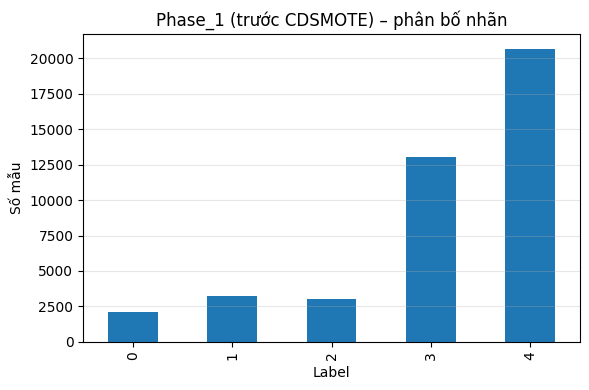

In [7]:
describe_and_plot_labels(
    df_phase1,
    target_col=LABEL_COL,
    title_prefix="Phase_1 (trước CDSMOTE)"
)


In [8]:
df_phase1_cd = cdsmote_resample_multiclass(
    df=df_phase1,
    feature_cols=feature_cols_phase1,
    target_col=LABEL_COL,
    k_clusters=2,
    k_neighbors=4,
    random_state=42,
)

print("Phase_1 – shape sau CDSMOTE:", df_phase1_cd.shape)


=== CDSMOTE multi-class ===
Phân bố nhãn ban đầu: {0: 2085, 1: 3240, 2: 3033, 3: 13042, 4: 20700}
Max count (majority lớn nhất): 20700

--- Xử lý class = 0 ---
  - Số mẫu class 0: 2085
  - Số mẫu majority (y != 0): 40015
  - Số mẫu từng subclass majority: [35228, 4787]
  - Mean size các subclass majority: 20007.50
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 20008 mẫu cho class 0
  - Số mẫu minority mới sinh thêm cho class 0: 17923

--- Xử lý class = 1 ---
  - Số mẫu class 1: 3240
  - Số mẫu majority (y != 1): 38860
  - Số mẫu từng subclass majority: [4234, 34626]
  - Mean size các subclass majority: 19430.00
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 19430 mẫu cho class 1
  - Số mẫu minority mới sinh thêm cho class 1: 16190

--- Xử lý class = 2 ---
  - Số mẫu class 2: 3033
  - Số mẫu majority (y != 2): 39067
  - Số mẫu từng subclass majority: [4481, 34586]
  - Mean size các subclass majority: 19533.50
  - Chọn subclass ma


=== Phase_1 (sau CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0    20008
1    19430
2    19534
3    14529
4    20700
Name: count, dtype: int64
Tổng số mẫu: 94201
Imbalance ratio (majority/minority): 1.42


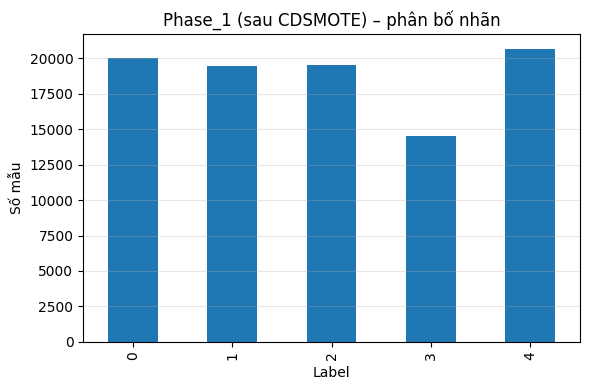

In [9]:
describe_and_plot_labels(
    df_phase1_cd,
    target_col=LABEL_COL,
    title_prefix="Phase_1 (sau CDSMOTE)"
)


In [10]:
out_dir = "/kaggle/working/cdsmote_trains"
os.makedirs(out_dir, exist_ok=True)

out_path1 = os.path.join(out_dir, "Phase_1_train_cdsmote.csv")
df_phase1_cd.to_csv(out_path1, index=False)

print("Đã lưu Phase_1 sau CDSMOTE tại:", out_path1)


Đã lưu Phase_1 sau CDSMOTE tại: /kaggle/working/cdsmote_trains/Phase_1_train_cdsmote.csv


# PHASE 2

In [11]:
BASE_DIR = "/kaggle/input/mooccubex-data-cleaned/Train_val_test_split/corr_data"
LABEL_COL = "label_5_encoder"   # cột nhãn 5 lớp đã encode

phase1_path = os.path.join(BASE_DIR, "Phase_2", "train.csv")
df_phase1 = pd.read_csv(phase1_path)

print("Phase_2 – shape gốc:", df_phase1.shape)
print("Các cột trong file:")
print(df_phase1.columns.tolist())

# Chọn feature: TẤT CẢ cột numeric trừ cột nhãn
feature_cols_phase1 = [
    c for c in df_phase1.columns
    if c != LABEL_COL and pd.api.types.is_numeric_dtype(df_phase1[c])
]
print("Số feature dùng cho CDSMOTE (Phase_2):", len(feature_cols_phase1))


Phase_2 – shape gốc: (39180, 88)
Các cột trong file:
['course_duration', 'num_course_order', 'avg_interval_enroll_time', 'max_interval_enroll_time', 'min_interval_enroll_time', 'first_enroll_year', 'last_enroll_year', 'most_enroll_month', 'enroll_ratio', 'video_counts', 'ex_counts', 'about_len', 'school_about_len', 'teacher_about_len', 'user_counts', 'average_attempts_1', 'average_ratio_1', 'average_exercise_time_1', 'average_time_between_submissions_1', 'average_enroll_to_first_submit_days_1', 'exercise_completion_ratio_1', 'segment_duration_seconds_1', 'segment_count_1', 'avg_playback_speed_1', 'avg_day_of_week_1', 'most_common_hour_1', 'unique_video_count_1', 'avg_segment_count_per_video_1', 'var_playback_speed_1', 'fast_forward_ratio_1', 'session_duration_std_1', 'time_bin_phase1', 'entropy_time_comment_phase1', 'total_words_phase1', 'total_negative_phase1', 'total_neutral_phase1', 'total_positive_phase1', 'total_comments_phase1', 'avg_comment_length_phase1', 'std_comment_length_ph


=== Phase_2 (trước CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0     2001
1     3126
2     2855
3    12010
4    19188
Name: count, dtype: int64
Tổng số mẫu: 39180
Imbalance ratio (majority/minority): 9.59


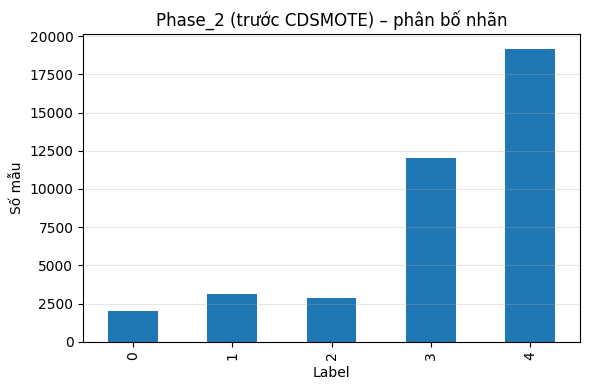

In [12]:
describe_and_plot_labels(
    df_phase1,
    target_col=LABEL_COL,
    title_prefix="Phase_2 (trước CDSMOTE)"
)


In [13]:
df_phase1_cd = cdsmote_resample_multiclass(
    df=df_phase1,
    feature_cols=feature_cols_phase1,
    target_col=LABEL_COL,
    k_clusters=2,
    k_neighbors=4,
    random_state=42,
)

print("Phase_2 – shape sau CDSMOTE:", df_phase1_cd.shape)


=== CDSMOTE multi-class ===
Phân bố nhãn ban đầu: {0: 2001, 1: 3126, 2: 2855, 3: 12010, 4: 19188}
Max count (majority lớn nhất): 19188

--- Xử lý class = 0 ---
  - Số mẫu class 0: 2001
  - Số mẫu majority (y != 0): 37179
  - Số mẫu từng subclass majority: [35432, 1747]
  - Mean size các subclass majority: 18589.50
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 18590 mẫu cho class 0
  - Số mẫu minority mới sinh thêm cho class 0: 16589

--- Xử lý class = 1 ---
  - Số mẫu class 1: 3126
  - Số mẫu majority (y != 1): 36054
  - Số mẫu từng subclass majority: [32694, 3360]
  - Mean size các subclass majority: 18027.00
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 18027 mẫu cho class 1
  - Số mẫu minority mới sinh thêm cho class 1: 14901

--- Xử lý class = 2 ---
  - Số mẫu class 2: 2855
  - Số mẫu majority (y != 2): 36325
  - Số mẫu từng subclass majority: [3455, 32870]
  - Mean size các subclass majority: 18162.50
  - Chọn subclass ma

In [14]:
df_phase1_cd = cdsmote_resample_multiclass(
    df=df_phase1,
    feature_cols=feature_cols_phase1,
    target_col=LABEL_COL,
    k_clusters=2,
    k_neighbors=4,
    random_state=42,
)

print("Phase_2 – shape sau CDSMOTE:", df_phase1_cd.shape)


=== CDSMOTE multi-class ===
Phân bố nhãn ban đầu: {0: 2001, 1: 3126, 2: 2855, 3: 12010, 4: 19188}
Max count (majority lớn nhất): 19188

--- Xử lý class = 0 ---
  - Số mẫu class 0: 2001
  - Số mẫu majority (y != 0): 37179
  - Số mẫu từng subclass majority: [35432, 1747]
  - Mean size các subclass majority: 18589.50
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 18590 mẫu cho class 0
  - Số mẫu minority mới sinh thêm cho class 0: 16589

--- Xử lý class = 1 ---
  - Số mẫu class 1: 3126
  - Số mẫu majority (y != 1): 36054
  - Số mẫu từng subclass majority: [32694, 3360]
  - Mean size các subclass majority: 18027.00
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 18027 mẫu cho class 1
  - Số mẫu minority mới sinh thêm cho class 1: 14901

--- Xử lý class = 2 ---
  - Số mẫu class 2: 2855
  - Số mẫu majority (y != 2): 36325
  - Số mẫu từng subclass majority: [3455, 32870]
  - Mean size các subclass majority: 18162.50
  - Chọn subclass ma


=== Phase_2 (sau CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0    18590
1    18027
2    18162
3    13585
4    19188
Name: count, dtype: int64
Tổng số mẫu: 87552
Imbalance ratio (majority/minority): 1.41


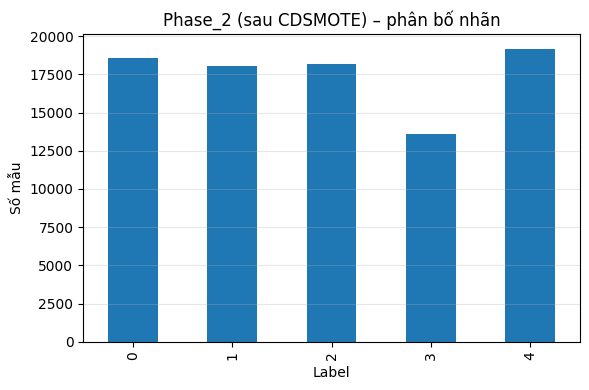

In [15]:
describe_and_plot_labels(
    df_phase1_cd,
    target_col=LABEL_COL,
    title_prefix="Phase_2 (sau CDSMOTE)"
)


In [16]:
out_dir = "/kaggle/working/cdsmote_trains"
os.makedirs(out_dir, exist_ok=True)

out_path1 = os.path.join(out_dir, "Phase_2_train_cdsmote.csv")
df_phase1_cd.to_csv(out_path1, index=False)

print("Đã lưu Phase_2 sau CDSMOTE tại:", out_path1)


Đã lưu Phase_2 sau CDSMOTE tại: /kaggle/working/cdsmote_trains/Phase_2_train_cdsmote.csv


# PHASE 3

In [17]:
BASE_DIR = "/kaggle/input/mooccubex-data-cleaned/Train_val_test_split/corr_data"
LABEL_COL = "label_5_encoder"   # cột nhãn 5 lớp đã encode

phase3_path = os.path.join(BASE_DIR, "Phase_3", "train.csv")
df_phase3 = pd.read_csv(phase3_path)

print("Phase_3 – shape gốc:", df_phase3.shape)
print("Các cột trong file:")
print(df_phase3.columns.tolist())

# Chọn feature: TẤT CẢ cột numeric trừ cột nhãn
feature_cols_phase3 = [
    c for c in df_phase3.columns
    if c != LABEL_COL and pd.api.types.is_numeric_dtype(df_phase3[c])
]
print("Số feature dùng cho CDSMOTE (Phase_3):", len(feature_cols_phase3))


Phase_3 – shape gốc: (37020, 123)
Các cột trong file:
['course_duration', 'num_course_order', 'avg_interval_enroll_time', 'max_interval_enroll_time', 'min_interval_enroll_time', 'first_enroll_year', 'last_enroll_year', 'most_enroll_month', 'enroll_ratio', 'video_counts', 'ex_counts', 'about_len', 'school_about_len', 'teacher_about_len', 'user_counts', 'average_attempts_1', 'average_ratio_1', 'average_exercise_time_1', 'average_time_between_submissions_1', 'average_enroll_to_first_submit_days_1', 'exercise_completion_ratio_1', 'segment_duration_seconds_1', 'segment_count_1', 'avg_playback_speed_1', 'avg_day_of_week_1', 'most_common_hour_1', 'unique_video_count_1', 'avg_segment_count_per_video_1', 'var_playback_speed_1', 'fast_forward_ratio_1', 'session_duration_std_1', 'time_bin_phase1', 'entropy_time_comment_phase1', 'total_words_phase1', 'total_negative_phase1', 'total_neutral_phase1', 'total_positive_phase1', 'total_comments_phase1', 'avg_comment_length_phase1', 'std_comment_length_p


=== Phase_3 (trước CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0     1882
1     2906
2     2621
3    11175
4    18436
Name: count, dtype: int64
Tổng số mẫu: 37020
Imbalance ratio (majority/minority): 9.80


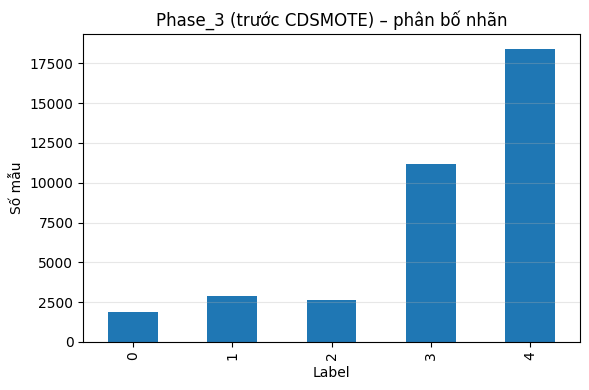

In [18]:
describe_and_plot_labels(
    df_phase3,
    target_col=LABEL_COL,
    title_prefix="Phase_3 (trước CDSMOTE)"
)


In [19]:
df_phase3_cd = cdsmote_resample_multiclass(
    df=df_phase3,
    feature_cols=feature_cols_phase3,
    target_col=LABEL_COL,
    k_clusters=2,
    k_neighbors=4,
    random_state=42,
)

print("Phase_3 – shape sau CDSMOTE:", df_phase3_cd.shape)


=== CDSMOTE multi-class ===
Phân bố nhãn ban đầu: {0: 1882, 1: 2906, 2: 2621, 3: 11175, 4: 18436}
Max count (majority lớn nhất): 18436

--- Xử lý class = 0 ---
  - Số mẫu class 0: 1882
  - Số mẫu majority (y != 0): 35138
  - Số mẫu từng subclass majority: [4186, 30952]
  - Mean size các subclass majority: 17569.00
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 17569 mẫu cho class 0
  - Số mẫu minority mới sinh thêm cho class 0: 15687

--- Xử lý class = 1 ---
  - Số mẫu class 1: 2906
  - Số mẫu majority (y != 1): 34114
  - Số mẫu từng subclass majority: [3142, 30972]
  - Mean size các subclass majority: 17057.00
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 17057 mẫu cho class 1
  - Số mẫu minority mới sinh thêm cho class 1: 14151

--- Xử lý class = 2 ---
  - Số mẫu class 2: 2621
  - Số mẫu majority (y != 2): 34399
  - Số mẫu từng subclass majority: [31404, 2995]
  - Mean size các subclass majority: 17199.50
  - Chọn subclass ma


=== Phase_3 (sau CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0    17569
1    17057
2    17200
3    12922
4    18436
Name: count, dtype: int64
Tổng số mẫu: 83184
Imbalance ratio (majority/minority): 1.43


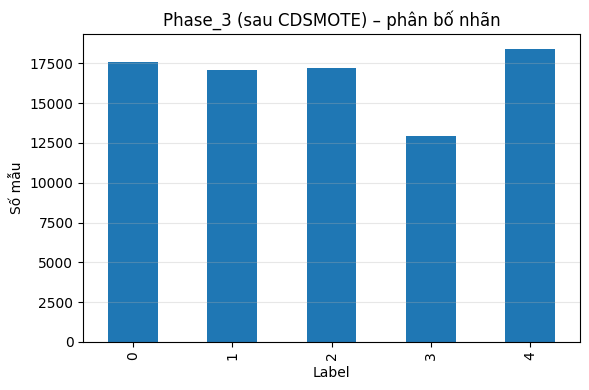

In [20]:
describe_and_plot_labels(
    df_phase3_cd,
    target_col=LABEL_COL,
    title_prefix="Phase_3 (sau CDSMOTE)"
)


In [21]:
out_dir = "/kaggle/working/cdsmote_trains"
os.makedirs(out_dir, exist_ok=True)

out_path3 = os.path.join(out_dir, "Phase_3_train_cdsmote.csv")
df_phase3_cd.to_csv(out_path3, index=False)

print("Đã lưu Phase_3 sau CDSMOTE tại:", out_path3)


Đã lưu Phase_3 sau CDSMOTE tại: /kaggle/working/cdsmote_trains/Phase_3_train_cdsmote.csv


# PHASE 4

In [22]:
BASE_DIR = "/kaggle/input/mooccubex-data-cleaned/Train_val_test_split/corr_data"
LABEL_COL = "label_5_encoder"

phase4_path = os.path.join(BASE_DIR, "Phase_4", "train.csv")
df_phase4 = pd.read_csv(phase4_path)

print("Phase_4 – shape gốc:", df_phase4.shape)
print("Các cột trong file:")
print(df_phase4.columns.tolist())

feature_cols_phase4 = [
    c for c in df_phase4.columns
    if c != LABEL_COL and pd.api.types.is_numeric_dtype(df_phase4[c])
]
print("Số feature dùng cho CDSMOTE (Phase_4):", len(feature_cols_phase4))


Phase_4 – shape gốc: (33680, 157)
Các cột trong file:
['course_duration', 'num_course_order', 'avg_interval_enroll_time', 'max_interval_enroll_time', 'min_interval_enroll_time', 'first_enroll_year', 'last_enroll_year', 'most_enroll_month', 'enroll_ratio', 'video_counts', 'ex_counts', 'about_len', 'school_about_len', 'teacher_about_len', 'user_counts', 'average_attempts_1', 'average_ratio_1', 'average_exercise_time_1', 'average_time_between_submissions_1', 'average_enroll_to_first_submit_days_1', 'exercise_completion_ratio_1', 'segment_duration_seconds_1', 'segment_count_1', 'avg_playback_speed_1', 'avg_day_of_week_1', 'most_common_hour_1', 'unique_video_count_1', 'avg_segment_count_per_video_1', 'var_playback_speed_1', 'fast_forward_ratio_1', 'session_duration_std_1', 'time_bin_phase1', 'entropy_time_comment_phase1', 'total_words_phase1', 'total_negative_phase1', 'total_neutral_phase1', 'total_positive_phase1', 'total_comments_phase1', 'avg_comment_length_phase1', 'std_comment_length_p


=== Phase_4 (trước CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0     1753
1     2447
2     2209
3     9931
4    17340
Name: count, dtype: int64
Tổng số mẫu: 33680
Imbalance ratio (majority/minority): 9.89


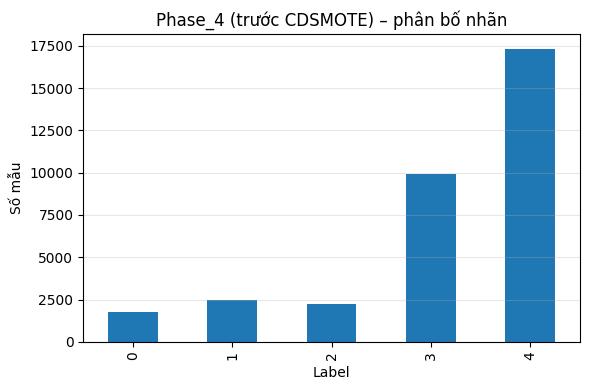

In [23]:
describe_and_plot_labels(
    df_phase4,
    target_col=LABEL_COL,
    title_prefix="Phase_4 (trước CDSMOTE)"
)


In [24]:
df_phase4_cd = cdsmote_resample_multiclass(
    df=df_phase4,
    feature_cols=feature_cols_phase4,
    target_col=LABEL_COL,
    k_clusters=2,
    k_neighbors=4,
    random_state=42,
)

print("Phase_4 – shape sau CDSMOTE:", df_phase4_cd.shape)


=== CDSMOTE multi-class ===
Phân bố nhãn ban đầu: {0: 1753, 1: 2447, 2: 2209, 3: 9931, 4: 17340}
Max count (majority lớn nhất): 17340

--- Xử lý class = 0 ---
  - Số mẫu class 0: 1753
  - Số mẫu majority (y != 0): 31927
  - Số mẫu từng subclass majority: [3494, 28433]
  - Mean size các subclass majority: 15963.50
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 15964 mẫu cho class 0
  - Số mẫu minority mới sinh thêm cho class 0: 14211

--- Xử lý class = 1 ---
  - Số mẫu class 1: 2447
  - Số mẫu majority (y != 1): 31233
  - Số mẫu từng subclass majority: [3350, 27883]
  - Mean size các subclass majority: 15616.50
  - Chọn subclass majority gần mean nhất: cluster 0
  - Mục tiêu sau SMOTE: 15616 mẫu cho class 1
  - Số mẫu minority mới sinh thêm cho class 1: 13169

--- Xử lý class = 2 ---
  - Số mẫu class 2: 2209
  - Số mẫu majority (y != 2): 31471
  - Số mẫu từng subclass majority: [3532, 27939]
  - Mean size các subclass majority: 15735.50
  - Chọn subclass maj


=== Phase_4 (sau CDSMOTE) – thống kê nhãn (label_5_encoder) ===
label_5_encoder
0    15964
1    15616
2    15736
3    11874
4    17340
Name: count, dtype: int64
Tổng số mẫu: 76530
Imbalance ratio (majority/minority): 1.46


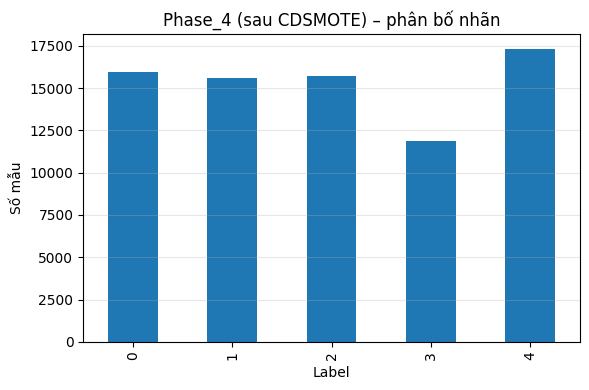

In [25]:
describe_and_plot_labels(
    df_phase4_cd,
    target_col=LABEL_COL,
    title_prefix="Phase_4 (sau CDSMOTE)"
)


In [26]:
out_dir = "/kaggle/working/cdsmote_trains"
os.makedirs(out_dir, exist_ok=True)

out_path4 = os.path.join(out_dir, "Phase_4_train_cdsmote.csv")
df_phase4_cd.to_csv(out_path4, index=False)

print("Đã lưu Phase_4 sau CDSMOTE tại:", out_path4)


Đã lưu Phase_4 sau CDSMOTE tại: /kaggle/working/cdsmote_trains/Phase_4_train_cdsmote.csv
